# 基于 ML 传感器构建交通图

- 数据源：sensors_common_2025.csv（全年存在的传感器）
- 只保留 ML（主线）传感器
- 按 Fwy + Dir 分组，Abs_PM 排序，相邻节点连边
- 边权重：高斯核函数（基于距离）
- 有向图：边方向与行驶方向一致

## 1. 环境配置

In [3]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import os

OUTPUT_DIR = "../output"
META_DIR = "../d03_meta_processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 2. 加载数据并筛选 ML 传感器

In [4]:
# 加载全年存在的传感器
df = pd.read_csv(os.path.join(META_DIR, 'sensors_common_2025.csv'), dtype={'ID': str, 'Fwy': str})
print(f"全部传感器数: {len(df)}")

# 筛选 ML（主线）传感器
ml_df = df[df['Type'] == 'ML'].copy()
print(f"ML 传感器数: {len(ml_df)}")

# 查看数据
display(ml_df[['ID', 'Fwy', 'Dir', 'Abs_PM', 'Latitude', 'Longitude', 'Lanes', 'Name']].head(10))

全部传感器数: 1830
ML 传感器数: 854


,ID,Fwy,Dir,Abs_PM,Latitude,Longitude,Lanes,Name
0,308511,50,E,60.162,38.761062,-120.569835,2,Sly Park Rd
1,308512,50,W,60.166,38.761182,-120.569866,2,Sly Park Rd
7,311903,50,E,3.789,38.566906,-121.505888,3,50EB at 6TH Street
10,311974,50,E,4.376,38.564153,-121.495585,5,15th St
12,312010,50,W,4.501,38.563816,-121.493316,5,15th St
15,312098,50,E,5.496,38.559020,-121.476106,4,28th St
17,312103,50,W,6.221,38.560995,-121.462999,4,Stockton Blvd
21,312132,5,S,506.189,38.409782,-121.484120,2,5SB at Elk Grove Blvd
22,312133,5,N,507.476,38.428229,-121.487572,3,5NB at Laguna Blvd
23,312134,5,N,506.373,38.412421,-121.484289,2,5NB at Elk Grove Blvd


In [5]:
# 统计
print("按高速公路统计:")
print(ml_df.groupby(['Fwy', 'Dir']).size().sort_values(ascending=False).head(15))

按高速公路统计:
Fwy  Dir
50   E      107
     W      103
80   E       98
     W       95
99   S       82
     N       75
5    N       54
     S       54
51   N       22
     S       19
65   S       17
     N       15
20   W       11
     E        9
70   E        8
dtype: int64


## 3. 定义高斯核函数

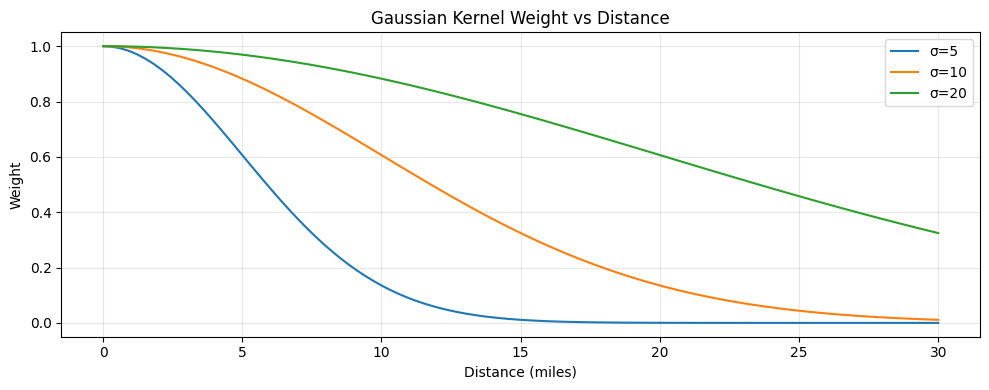

sigma 参数说明:
- sigma 越小，权重衰减越快，只有很近的传感器有较大权重
- sigma 越大，权重衰减越慢，较远的传感器也有一定权重


In [6]:
def gaussian_kernel(distance, sigma=10.0):
    """
    高斯核函数计算边权重
    
    weight = exp(-d^2 / (2 * sigma^2))
    
    - distance: 两传感器间的距离（英里，基于 Abs_PM）
    - sigma: 带宽参数，控制权重衰减速度
    
    返回值范围 (0, 1]，距离越近权重越大
    """
    return np.exp(-distance**2 / (2 * sigma**2))


# 可视化高斯核函数
distances = np.linspace(0, 30, 100)
fig, ax = plt.subplots(figsize=(10, 4))
for sigma in [5, 10, 20]:
    weights = gaussian_kernel(distances, sigma)
    ax.plot(distances, weights, label=f'σ={sigma}')
ax.set_xlabel('Distance (miles)')
ax.set_ylabel('Weight')
ax.set_title('Gaussian Kernel Weight vs Distance')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("sigma 参数说明:")
print("- sigma 越小，权重衰减越快，只有很近的传感器有较大权重")
print("- sigma 越大，权重衰减越慢，较远的传感器也有一定权重")

## 4. 构建有向图

In [7]:
def build_traffic_graph(ml_df, sigma=10.0):
    """
    构建交通有向图
    
    边方向规则（与行驶方向一致）：
    - N/E 方向：Abs_PM 小 → Abs_PM 大
    - S/W 方向：Abs_PM 大 → Abs_PM 小
    """
    G = nx.DiGraph()
    
    # 添加所有节点
    for _, row in ml_df.iterrows():
        G.add_node(row['ID'], 
                   fwy=row['Fwy'],
                   dir=row['Dir'],
                   abs_pm=row['Abs_PM'],
                   lat=row['Latitude'],
                   lon=row['Longitude'],
                   lanes=row['Lanes'],
                   name=row['Name'])
    
    # 按 Fwy + Dir 分组构建边
    edge_count = 0
    for (fwy, direction), group in ml_df.groupby(['Fwy', 'Dir']):
        # 按 Abs_PM 排序
        sorted_group = group.sort_values('Abs_PM').reset_index(drop=True)
        
        # 相邻节点连边
        for i in range(len(sorted_group) - 1):
            node1 = sorted_group.iloc[i]
            node2 = sorted_group.iloc[i + 1]
            
            # 计算距离和权重
            distance = abs(node2['Abs_PM'] - node1['Abs_PM'])
            weight = gaussian_kernel(distance, sigma)
            
            # 确定边方向（与行驶方向一致）
            if direction in ['N', 'E']:  # 北/东：PM递增方向
                src, dst = node1['ID'], node2['ID']
            else:  # 南/西：PM递减方向
                src, dst = node2['ID'], node1['ID']
            
            G.add_edge(src, dst, 
                       distance=distance, 
                       weight=weight,
                       fwy=fwy,
                       dir=direction)
            edge_count += 1
    
    print(f"节点数: {G.number_of_nodes()}")
    print(f"边数: {G.number_of_edges()}")
    
    return G


# 构建图
SIGMA = 10.0  # 高斯核带宽参数
G = build_traffic_graph(ml_df, sigma=SIGMA)
print(f"\n使用 sigma = {SIGMA}")

节点数: 854
边数: 814

使用 sigma = 10.0


## 5. 图统计信息

In [8]:
# 基本统计
print("=" * 50)
print("图统计信息")
print("=" * 50)
print(f"节点数: {G.number_of_nodes()}")
print(f"边数: {G.number_of_edges()}")
print(f"是否有向图: {G.is_directed()}")

# 连通分量
weakly_connected = list(nx.weakly_connected_components(G))
print(f"弱连通分量数: {len(weakly_connected)}")
print(f"最大分量节点数: {max(len(c) for c in weakly_connected)}")

# 边权重统计
distances = [G.edges[e]['distance'] for e in G.edges]
weights = [G.edges[e]['weight'] for e in G.edges]

print(f"\n边距离统计 (miles):")
print(f"  最小: {min(distances):.3f}")
print(f"  最大: {max(distances):.3f}")
print(f"  平均: {np.mean(distances):.3f}")

print(f"\n边权重统计:")
print(f"  最小: {min(weights):.4f}")
print(f"  最大: {max(weights):.4f}")
print(f"  平均: {np.mean(weights):.4f}")

图统计信息
节点数: 854
边数: 814
是否有向图: True
弱连通分量数: 40
最大分量节点数: 107

边距离统计 (miles):
  最小: 0.000
  最大: 36.372
  平均: 1.867

边权重统计:
  最小: 0.0013
  最大: 1.0000
  平均: 0.9518


In [9]:
# 按高速公路统计边数
edge_by_fwy = {}
for u, v, data in G.edges(data=True):
    key = f"{data['fwy']}{data['dir']}"
    edge_by_fwy[key] = edge_by_fwy.get(key, 0) + 1

print("\n各高速公路边数:")
for k, v in sorted(edge_by_fwy.items(), key=lambda x: -x[1])[:15]:
    print(f"  {k}: {v}")


各高速公路边数:
  50E: 106
  50W: 102
  80E: 97
  80W: 94
  99S: 81
  99N: 74
  5S: 53
  5N: 53
  51N: 21
  51S: 18
  65S: 16
  65N: 14
  20W: 10
  20E: 8
  70E: 7


## 6. 可视化

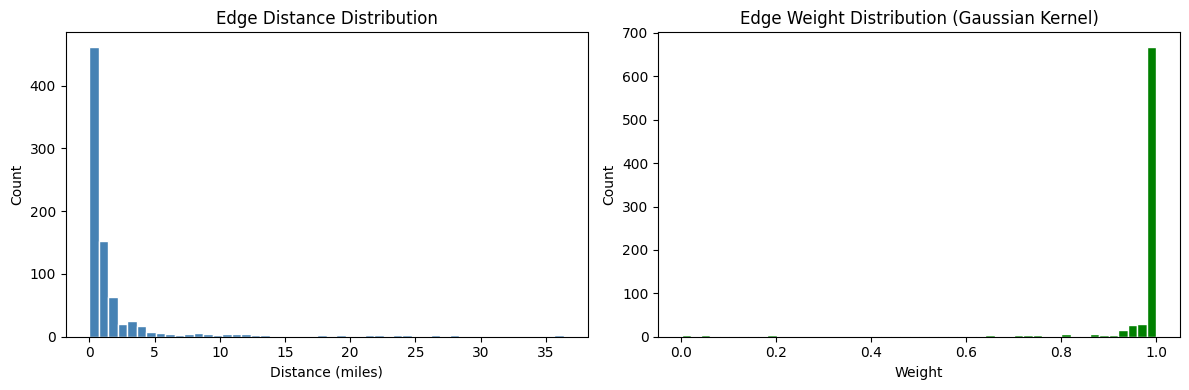

In [10]:
# 距离和权重分布
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(distances, bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Distance (miles)')
axes[0].set_ylabel('Count')
axes[0].set_title('Edge Distance Distribution')

axes[1].hist(weights, bins=50, color='green', edgecolor='white')
axes[1].set_xlabel('Weight')
axes[1].set_ylabel('Count')
axes[1].set_title('Edge Weight Distribution (Gaussian Kernel)')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'graph_edge_stats.png'), dpi=150)
plt.show()

I-80 : 193 节点, 191 边


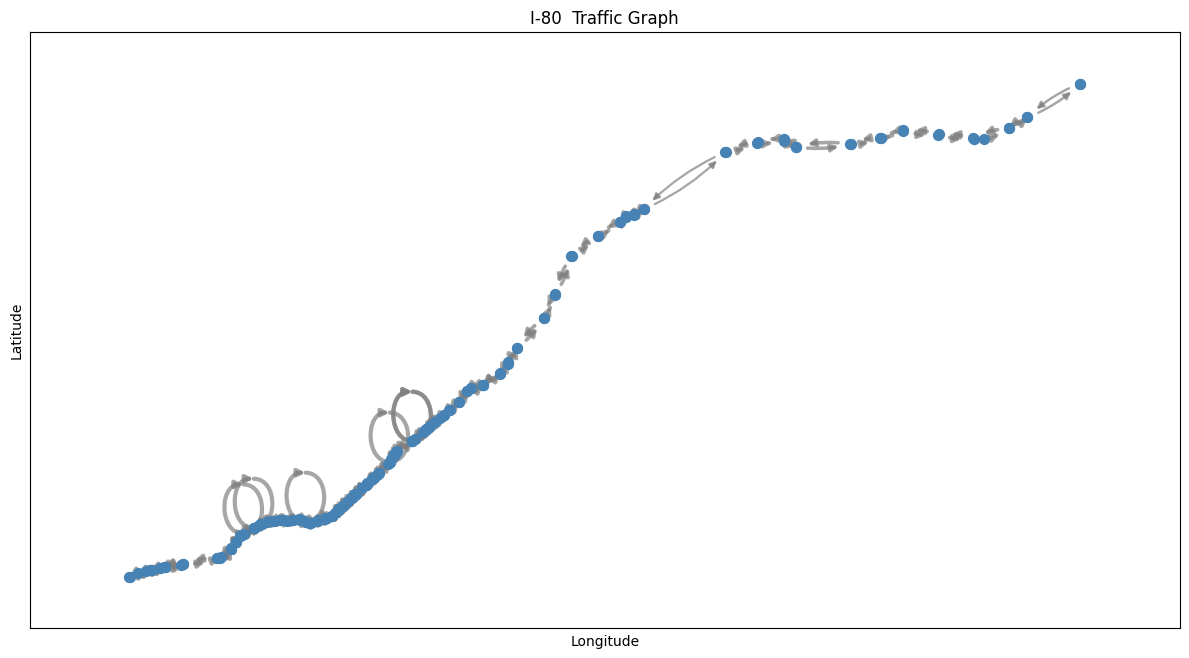

In [11]:
# 可视化特定高速公路的子图
def plot_freeway_subgraph(G, ml_df, fwy, direction=None):
    """
    可视化特定高速公路的子图
    """
    # 筛选节点
    nodes = [n for n, d in G.nodes(data=True) 
             if d['fwy'] == fwy and (direction is None or d['dir'] == direction)]
    
    if not nodes:
        print(f"未找到 {fwy} {direction or ''} 的节点")
        return
    
    subG = G.subgraph(nodes)
    print(f"I-{fwy} {direction or ''}: {subG.number_of_nodes()} 节点, {subG.number_of_edges()} 边")
    
    # 使用经纬度作为位置
    pos = {n: (G.nodes[n]['lon'], G.nodes[n]['lat']) for n in nodes}
    
    # 边权重作为宽度
    edge_weights = [subG.edges[e]['weight'] * 3 for e in subG.edges]
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    nx.draw_networkx_nodes(subG, pos, ax=ax, node_size=50, node_color='steelblue')
    nx.draw_networkx_edges(subG, pos, ax=ax, width=edge_weights, 
                           edge_color='gray', alpha=0.7,
                           arrows=True, arrowsize=10,
                           connectionstyle="arc3,rad=0.1")
    
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(f'I-{fwy} {direction or ""} Traffic Graph')
    ax.set_aspect('equal')
    
    plt.tight_layout()
    return fig


# 示例：I-80
fig = plot_freeway_subgraph(G, ml_df, '80')
if fig:
    plt.savefig(os.path.join(OUTPUT_DIR, 'graph_i80.png'), dpi=150)
    plt.show()

## 7. 导出邻接矩阵

In [12]:
# 获取节点顺序（按 Fwy, Dir, Abs_PM 排序）
node_order = ml_df.sort_values(['Fwy', 'Dir', 'Abs_PM'])['ID'].tolist()

# 创建邻接矩阵（权重矩阵）
adj_matrix = nx.to_numpy_array(G, nodelist=node_order, weight='weight')

print(f"邻接矩阵形状: {adj_matrix.shape}")
print(f"非零元素数: {np.count_nonzero(adj_matrix)}")
print(f"稀疏度: {1 - np.count_nonzero(adj_matrix) / adj_matrix.size:.4f}")

邻接矩阵形状: (854, 854)
非零元素数: 814
稀疏度: 0.9989


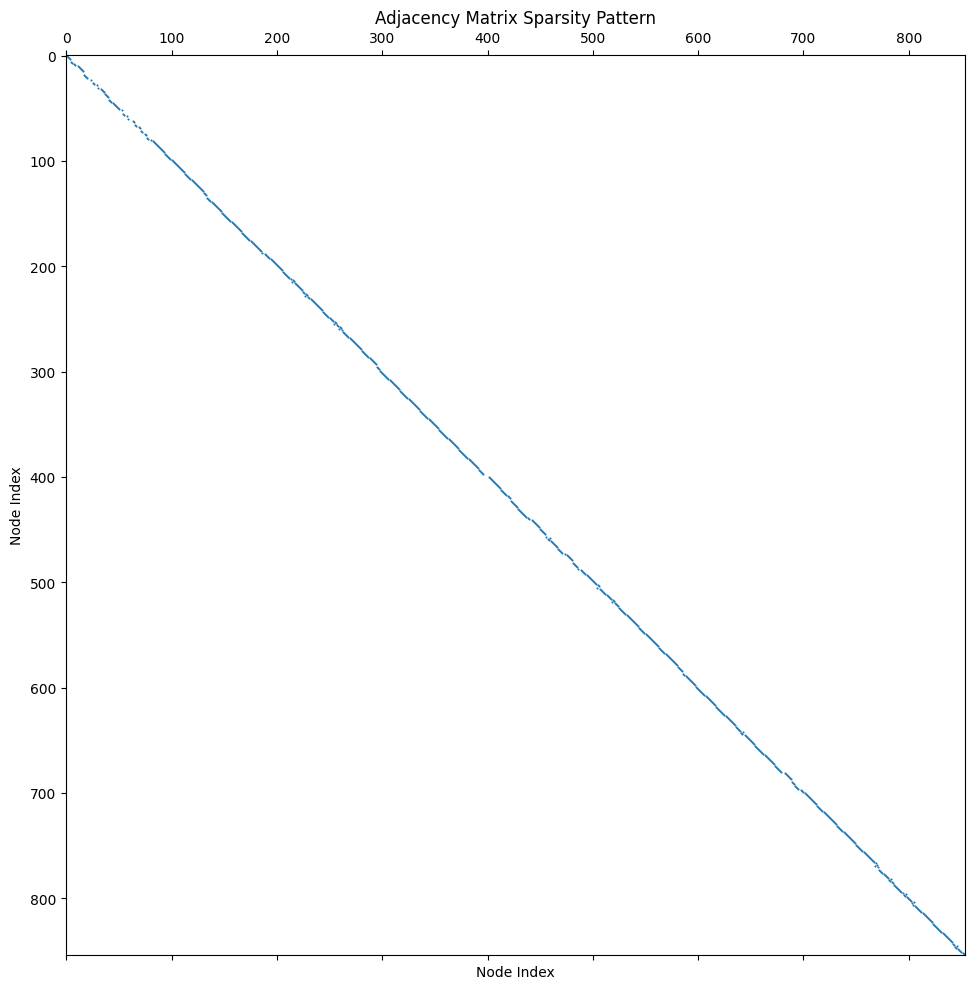

In [13]:
# 可视化邻接矩阵（稀疏模式）
fig, ax = plt.subplots(figsize=(10, 10))
ax.spy(adj_matrix, markersize=0.5)
ax.set_title('Adjacency Matrix Sparsity Pattern')
ax.set_xlabel('Node Index')
ax.set_ylabel('Node Index')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'adjacency_matrix_spy.png'), dpi=150)
plt.show()

## 8. 保存图数据

In [14]:
# 保存节点列表
node_data = []
for i, node_id in enumerate(node_order):
    d = G.nodes[node_id]
    node_data.append({
        'Index': i,
        'ID': node_id,
        'Fwy': d['fwy'],
        'Dir': d['dir'],
        'Abs_PM': d['abs_pm'],
        'Latitude': d['lat'],
        'Longitude': d['lon'],
        'Lanes': d['lanes'],
        'Name': d['name']
    })

node_df = pd.DataFrame(node_data)
node_df.to_csv(os.path.join(OUTPUT_DIR, 'graph_nodes.csv'), index=False)
print(f"节点列表已保存: graph_nodes.csv")

节点列表已保存: graph_nodes.csv


In [15]:
# 保存边列表
edge_data = []
node_to_idx = {node_id: i for i, node_id in enumerate(node_order)}

for u, v, d in G.edges(data=True):
    edge_data.append({
        'Source': u,
        'Target': v,
        'Source_Idx': node_to_idx[u],
        'Target_Idx': node_to_idx[v],
        'Distance': d['distance'],
        'Weight': d['weight'],
        'Fwy': d['fwy'],
        'Dir': d['dir']
    })

edge_df = pd.DataFrame(edge_data)
edge_df.to_csv(os.path.join(OUTPUT_DIR, 'graph_edges.csv'), index=False)
print(f"边列表已保存: graph_edges.csv")

边列表已保存: graph_edges.csv


In [16]:
# 保存邻接矩阵（numpy 格式）
np.save(os.path.join(OUTPUT_DIR, 'adjacency_matrix.npy'), adj_matrix)
print(f"邻接矩阵已保存: adjacency_matrix.npy")

# 保存节点顺序
np.save(os.path.join(OUTPUT_DIR, 'node_order.npy'), np.array(node_order))
print(f"节点顺序已保存: node_order.npy")

邻接矩阵已保存: adjacency_matrix.npy
节点顺序已保存: node_order.npy


In [17]:
# 保存为 GraphML 格式（可用 Gephi 等工具打开）
nx.write_graphml(G, os.path.join(OUTPUT_DIR, 'traffic_graph.graphml'))
print(f"GraphML 已保存: traffic_graph.graphml")

GraphML 已保存: traffic_graph.graphml


---
## 输出文件说明

| 文件 | 说明 |
|------|------|
| `graph_nodes.csv` | 节点列表（含索引、ID、属性） |
| `graph_edges.csv` | 边列表（含源、目标、距离、权重） |
| `adjacency_matrix.npy` | 邻接矩阵（numpy格式） |
| `node_order.npy` | 节点顺序（与邻接矩阵对应） |
| `traffic_graph.graphml` | GraphML格式（可视化工具用） |

### 使用示例

```python
# 加载邻接矩阵
adj = np.load('adjacency_matrix.npy')
nodes = np.load('node_order.npy', allow_pickle=True)

# 加载边列表
edges = pd.read_csv('graph_edges.csv')
```